First 5 rows:
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1

Decision Tree Accuracy: 0.9583333333333334
Bagging Accuracy: 0.9583333333333334


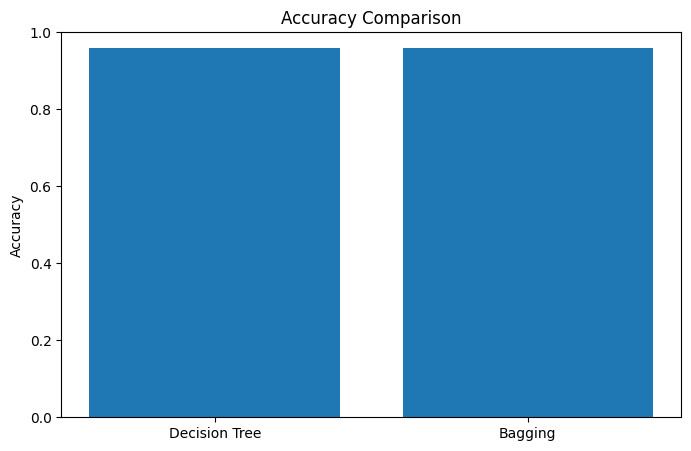

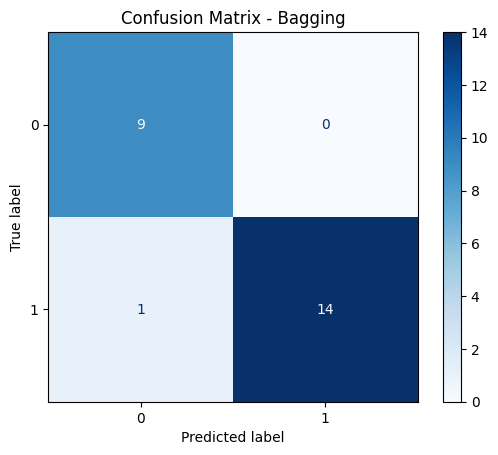

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("diabetes_bagging.csv")

print("First 5 rows:")
print(df.head())

# Split features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

# Train Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)
bag_acc = accuracy_score(y_test, y_pred_bag)

print("\nDecision Tree Accuracy:", dt_acc)
print("Bagging Accuracy:", bag_acc)

# Accuracy comparison bar graph
models = ["Decision Tree", "Bagging"]
accuracies = [dt_acc, bag_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Confusion matrix for Bagging
cm = confusion_matrix(y_test, y_pred_bag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Bagging")
plt.show()

First 5 rows:
   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0

Missing values:
Tenure              0
MonthlyCharges      0
ContractType        0
InternetService    43
Churn               0
dtype: int64

AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


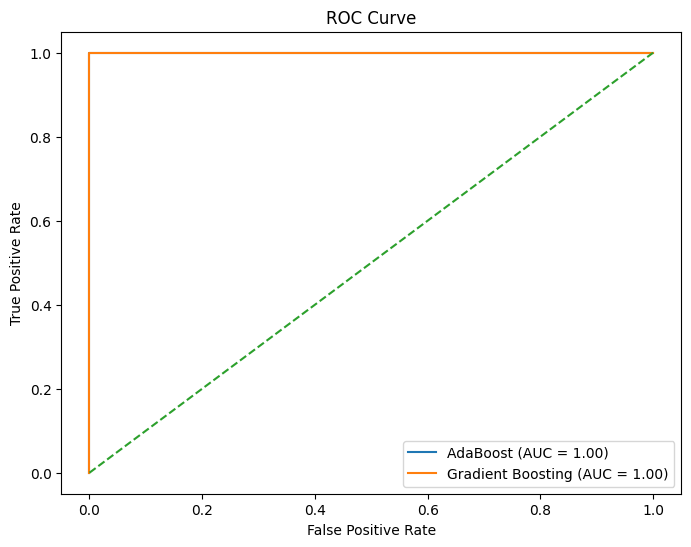


Top Feature Importances:
                       Feature  Importance
1               MonthlyCharges    0.609524
0                       Tenure    0.390476
2  ContractType_Month-to-month    0.000000
3        ContractType_One year    0.000000
4        ContractType_Two year    0.000000
5          InternetService_DSL    0.000000
6  InternetService_Fiber optic    0.000000


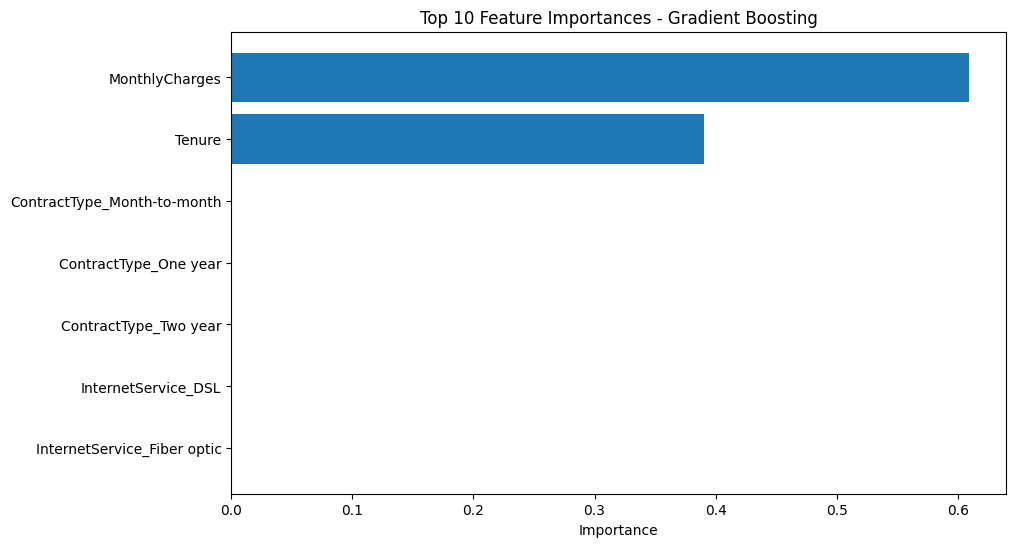

In [13]:
# SCENARIO 2 - BOOSTING
# Predict customer churn

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Load dataset
df = pd.read_csv("churn_boosting.csv")

print("First 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# AdaBoost pipeline
ada_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(n_estimators=100, random_state=42))
])

# Gradient Boosting pipeline
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=100, random_state=42))
])

# Train models
ada_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Predictions
y_pred_ada = ada_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Accuracy
ada_acc = accuracy_score(y_test, y_pred_ada)
gb_acc = accuracy_score(y_test, y_pred_gb)

print("\nAdaBoost Accuracy:", ada_acc)
print("Gradient Boosting Accuracy:", gb_acc)

# ROC Curve
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

roc_auc_ada = auc(fpr_ada, tpr_ada)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {roc_auc_ada:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {roc_auc_gb:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature importance for Gradient Boosting
# Get transformed feature names
ohe = gb_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = list(numeric_cols) + list(cat_feature_names)

importances = gb_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances:")
print(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"].head(10), feature_importance_df["Importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.show()

First 5 rows:
   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1
n_estimators=10, Accuracy=1.0000
n_estimators=30, Accuracy=1.0000
n_estimators=50, Accuracy=1.0000
n_estimators=70, Accuracy=1.0000
n_estimators=100, Accuracy=1.0000
n_estimators=150, Accuracy=1.0000
n_estimators=200, Accuracy=1.0000

Best number of trees: 10
Best accuracy: 1.0

Feature Importances:
          Feature  Importance
2    HoursPerWeek    0.591519
1  EducationYears    0.333541
0             Age    0.061988
3      Experience    0.012953


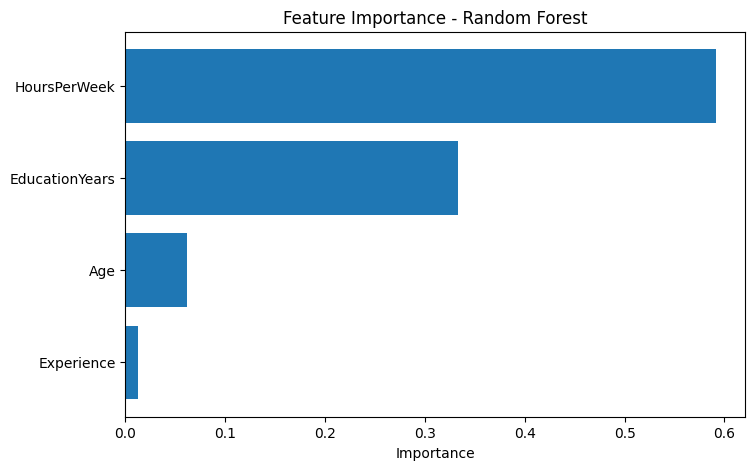

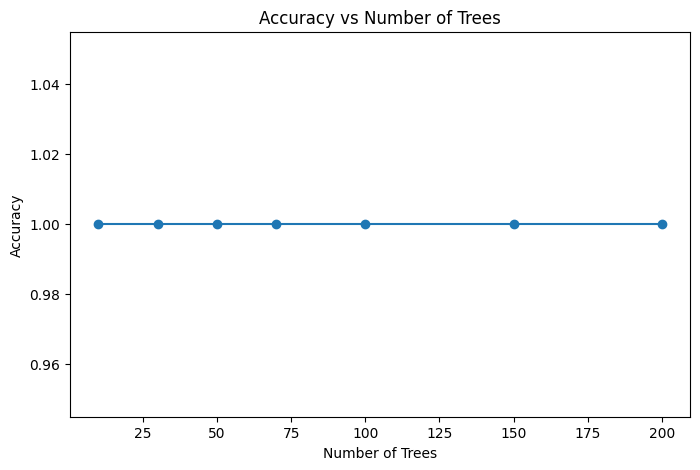

In [14]:
# SCENARIO 3 - RANDOM FOREST
# Predict whether income is >50K

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("income_random_forest.csv")

print("First 5 rows:")
print(df.head())

# Split features and target
X = df.drop("Income", axis=1)
y = df["Income"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tune number of trees
tree_range = [10, 30, 50, 70, 100, 150, 200]
accuracy_list = []

for n in tree_range:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)
    print(f"n_estimators={n}, Accuracy={acc:.4f}")

# Best model
best_n = tree_range[accuracy_list.index(max(accuracy_list))]
best_rf = RandomForestClassifier(n_estimators=best_n, random_state=42)
best_rf.fit(X_train, y_train)

print("\nBest number of trees:", best_n)
print("Best accuracy:", max(accuracy_list))

# Feature Importance
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importances:")
print(feature_importance_df)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

# Accuracy vs Number of Trees graph
plt.figure(figsize=(8, 5))
plt.plot(tree_range, accuracy_list, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()

First 5 rows:
   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0

Logistic Regression Accuracy: 0.7916666666666666
SVM Accuracy: 0.9583333333333334
Decision Tree Accuracy: 1.0
Stacking Accuracy: 1.0


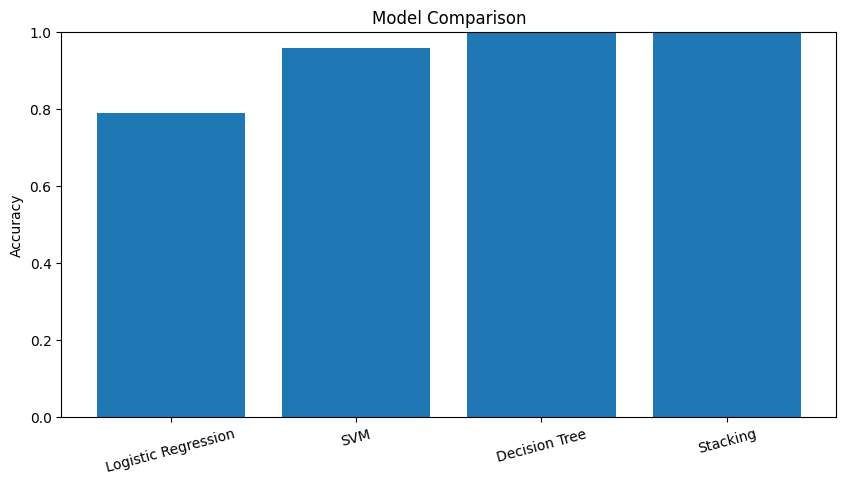

In [15]:
# SCENARIO 4 - STACKING
# Predict heart disease presence

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load dataset
df = pd.read_csv("heart_stacking.csv")

print("First 5 rows:")
print(df.head())

# Split features and target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Individual models
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(probability=True))
])

dt_model = DecisionTreeClassifier(random_state=42)

# Train and evaluate individual models
lr_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
svm_acc = accuracy_score(y_test, svm_model.predict(X_test))
dt_acc = accuracy_score(y_test, dt_model.predict(X_test))

# Stacking model
estimators = [
    ("lr", Pipeline([("scaler", StandardScaler()), ("classifier", LogisticRegression(max_iter=1000))])),
    ("svm", Pipeline([("scaler", StandardScaler()), ("classifier", SVC(probability=True))])),
    ("dt", DecisionTreeClassifier(random_state=42))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000)
)

stack_model.fit(X_train, y_train)
stack_acc = accuracy_score(y_test, stack_model.predict(X_test))

print("\nLogistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Stacking Accuracy:", stack_acc)

# Model comparison bar chart
models = ["Logistic Regression", "SVM", "Decision Tree", "Stacking"]
accuracies = [lr_acc, svm_acc, dt_acc, stack_acc]

plt.figure(figsize=(10, 5))
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

First 5 rows:
    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0

Class Distribution Before SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64

Classification Report Before SMOTE:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



c:\Users\Ram\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ram\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ram\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

Class Distribution After SMOTE:
Fraud
1    88
0    88
Name: count, dtype: int64

Classification Report After SMOTE:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        22
           1       0.00      0.00      0.00         2

    accuracy                           0.75        24
   macro avg       0.45      0.41      0.43        24
weighted avg       0.83      0.75      0.79        24



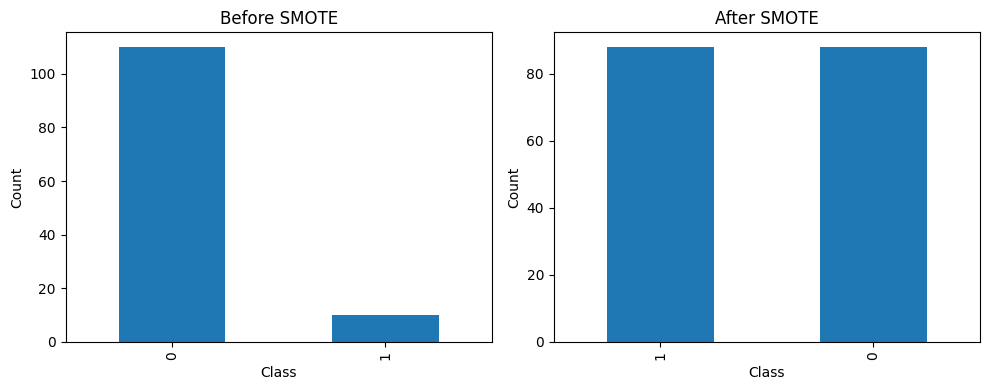

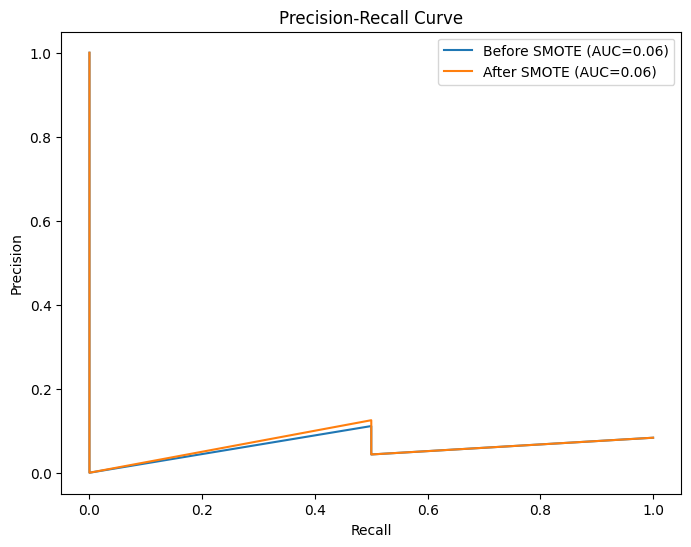

In [34]:
# SCENARIO 5 - SMOTE
# Detect fraudulent transactions

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("fraud_smote.csv")

print("First 5 rows:")
print(df.head())

# Check class imbalance
print("\nClass Distribution Before SMOTE:")
print(df["Fraud"].value_counts())

# Split features and target
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model before SMOTE
model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)
y_pred_before = model_before.predict(X_test)
y_score_before = model_before.predict_proba(X_test)[:, 1]

print("\nClassification Report Before SMOTE:")
print(classification_report(y_test, y_pred_before))

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class Distribution After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Train model after SMOTE
model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_train_smote, y_train_smote)
y_pred_after = model_after.predict(X_test)
y_score_after = model_after.predict_proba(X_test)[:, 1]

print("\nClassification Report After SMOTE:")
print(classification_report(y_test, y_pred_after))

# Visualization: Class distribution before and after SMOTE
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df["Fraud"].value_counts().plot(kind="bar")
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
pd.Series(y_train_smote).value_counts().plot(kind="bar")
plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision_before, recall_before, _ = precision_recall_curve(y_test, y_score_before)
precision_after, recall_after, _ = precision_recall_curve(y_test, y_score_after)

pr_auc_before = auc(recall_before, precision_before)
pr_auc_after = auc(recall_after, precision_after)

plt.figure(figsize=(8, 6))
plt.plot(recall_before, precision_before, label=f"Before SMOTE (AUC={pr_auc_before:.2f})")
plt.plot(recall_after, precision_after, label=f"After SMOTE (AUC={pr_auc_after:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [33]:
pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
